# Статистический анализ данных Wildberries

Цель работы — провести статистический анализ продаж, выявить зависимости между показателями и сформулировать практические выводы для бизнеса.

## 1. Загрузка данных и подготовка окружения

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('wb-data-test.csv')

df.head()

,бренд,артикул,дата,Прибыль,Себестоимость,Доставка,Обратная логистика,Комиссия WB,"Заказано, руб",% выкупа,...,"Заказы с внут. рекламы ""Поиск""",Заказы с каталога,Заказы с внеш. рекламы,Органика,Бюджет на рекламу,Бюджет на внутр рекламу,Внешняя реклама,Участие в Акции,Корзина,Заказы
0,kaoki,Штаны ментол - 399,01.06.2023,600,580,86,55,25%,25704,"73,39%",...,1.0,NaN,8.0,6.0,4765,3865.0,900.0,НЕТ,9.6%,12.5%
1,kaoki,Шорты ментол - 597,02.06.2023,-1548,580,86,55,25%,22680,"73,07%",...,1.0,NaN,6.0,10.0,3500,2000.0,0.0,НЕТ,NaN,NaN
2,kaoki,Шорты ментол - 597,03.06.2023,413,580,86,55,25%,33021,"72,96%",...,0.0,NaN,0.0,26.0,2000,2000.0,0.0,ДА,NaN,17.7%
3,kaoki,Шорты ментол - 597,04.06.2023,-2193,580,86,55,25%,38976,"72,37%",...,1.0,NaN,3.0,27.0,2950,2000.0,0.0,ДА,NaN,11.5%
4,kaoki,Шорты ментол - 597,05.06.2023,2448,580,86,55,25%,46410,"72,74%",...,0.0,NaN,10.0,23.0,1500,1000.0,1000.0,ДА,9.9%,NaN


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   бренд                              61 non-null     object 
 1   артикул                            183 non-null    object 
 2   дата                               183 non-null    object 
 3   Прибыль                            183 non-null    int64  
 4   Себестоимость                      183 non-null    int64  
 5   Доставка                           183 non-null    int64  
 6   Обратная логистика                 183 non-null    int64  
 7   Комиссия WB                        183 non-null    object 
 8   Заказано, руб                      183 non-null    int64  
 9   % выкупа                           183 non-null    object 
 10  Выкуплено, шт                      183 non-null    int64  
 11  Выкуплено на сумму                 183 non-null    object 

In [73]:
df.describe()

,Прибыль,Себестоимость,Доставка,Обратная логистика,"Заказано, руб","Выкуплено, шт","Отказы, шт","Возвраты, шт",Цена,Цена с СПП,Штрафы|Обезличка,Заказано,"Заказы с внут. рекламы ""Карточка""","Заказы с внут. рекламы ""Поиск""",Заказы с каталога,Заказы с внеш. рекламы,Органика,Бюджет на рекламу,Бюджет на внутр рекламу,Внешняя реклама
count,183.000000,183.000000,183.000000,183.0,183.000000,183.000000,183.000000,183.000000,183.000000,0.0,3.000000,183.000000,40.000000,40.000000,32.000000,44.000000,46.000000,183.000000,112.000000,89.000000
mean,4629.989071,898.251366,84.098361,55.0,39663.699454,12.224044,5.606557,0.284153,2311.786885,NaN,873.000000,19.442623,0.600000,0.300000,0.312500,11.318182,28.630435,1365.420765,516.428571,1304.505618
std,8691.988747,215.598330,8.731725,0.0,47806.139046,14.150644,6.154455,0.607752,400.310708,NaN,104.990476,24.101793,0.810191,0.563869,0.592289,17.505843,21.171636,4707.844803,772.691059,5585.041385
min,-18846.000000,580.000000,72.000000,55.0,0.000000,0.000000,0.000000,0.000000,1218.000000,NaN,806.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000
25%,0.000000,630.000000,75.000000,55.0,3808.000000,1.000000,1.000000,0.000000,2100.000000,NaN,812.500000,1.500000,0.000000,0.000000,0.000000,0.000000,19.000000,0.000000,0.000000,0.000000
50%,913.000000,1050.000000,86.000000,55.0,22400.000000,6.000000,4.000000,0.000000,2296.000000,NaN,819.000000,9.000000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000
75%,5515.500000,1050.000000,86.000000,55.0,60690.000000,21.500000,9.000000,0.000000,2688.000000,NaN,906.500000,29.000000,1.000000,0.250000,0.250000,17.250000,30.000000,729.000000,1000.000000,53.000000
max,37599.000000,1050.000000,110.000000,55.0,249900.000000,64.000000,27.000000,2.000000,2800.000000,NaN,994.000000,143.000000,3.000000,2.000000,2.000000,60.000000,143.000000,37100.000000,3865.000000,37100.000000


## 2. Предобработка данных

In [74]:
# проценты (% выкупа, комиссия, корзина, заказы)
cols_percent = ['% выкупа', 'Комиссия WB', 'Корзина', 'Заказы']

for col in cols_percent:
    df[col] = df[col].astype(str)\
                     .str.replace('%', '', regex=False)\
                     .str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [75]:
# дата
df['дата'] = pd.to_datetime(df['дата'], dayfirst=True)

In [76]:
# бинарная переменная акции
df['Акция'] = df['Участие в Акции'].map({'ДА': 1, 'НЕТ': 0})

In [77]:
# удаление плохих столбцов
df = df.drop(columns=['Цена с СПП', 'Штрафы|Обезличка'])

In [78]:
# заполнение пропусков
df = df.fillna(0)

## 3. Исследовательский анализ данных (EDA)

Анализ распределений и основных характеристик показателей.

In [79]:
# основные статистики
df[['Прибыль', 'Заказано', 'Цена', 'Бюджет на рекламу']].describe()

,Прибыль,Заказано,Цена,Бюджет на рекламу
count,183.000000,183.000000,183.000000,183.000000
mean,4629.989071,19.442623,2311.786885,1365.420765
std,8691.988747,24.101793,400.310708,4707.844803
min,-18846.000000,0.000000,1218.000000,0.000000
25%,0.000000,1.500000,2100.000000,0.000000
50%,913.000000,9.000000,2296.000000,0.000000
75%,5515.500000,29.000000,2688.000000,729.000000
max,37599.000000,143.000000,2800.000000,37100.000000


Прибыль: Средняя прибыль составляет около 4630, но с очень высоким стандартным отклонением (8692), что указывает на значительную волатильность. Наличие отрицательных значений (минимум -18846) говорит о существенных убытках в некоторые периоды. Медиана (913) значительно ниже среднего, что подтверждает асимметрию распределения с наличием высокоприбыльных, но редких операций.

Заказано: В среднем 19 заказов в день, с максимумом в 143. Наличие дней без заказов (минимум 0) требует внимания к причинам отсутствия активности.

Цена: Средняя цена 2311, с диапазоном от 1218 до 2800. Важно понимать, как эта цена соотносится с себестоимостью и конкурентами.

Бюджет на рекламу: Средний бюджет 1365, но с большим разбросом (стандартное отклонение 4707) и максимальным значением 37100. Это указывает на неравномерное распределение рекламных усилий и необходимость анализа их эффективности.

### Распределение прибыли

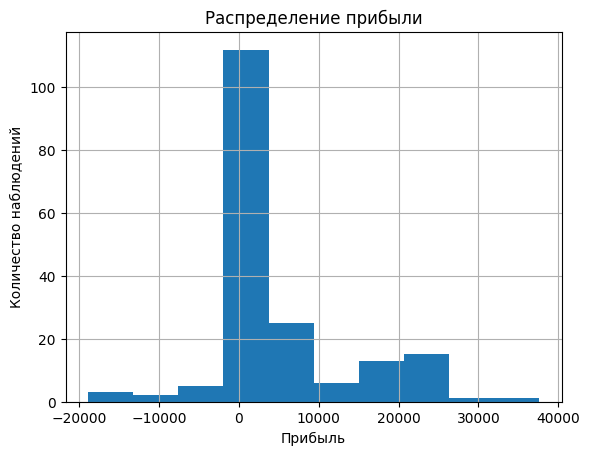

In [80]:
plt.figure()
df['Прибыль'].hist()
plt.title('Распределение прибыли')
plt.xlabel('Прибыль')
plt.ylabel('Количество наблюдений')
plt.show()

Распределение прибыли сильно скошено вправо, с основным объемом данных сосредоточенным вокруг нуля или небольших положительных значений. Это означает, что большинство операций приносят небольшую прибыль или убытки. Наличие значительных положительных выбросов (высокая прибыль) и отрицательных значений (убытки) подчеркивает неоднородность финансовых результатов. Для бизнеса это сигнал к поиску причин убыточности и масштабированию успешных практик.

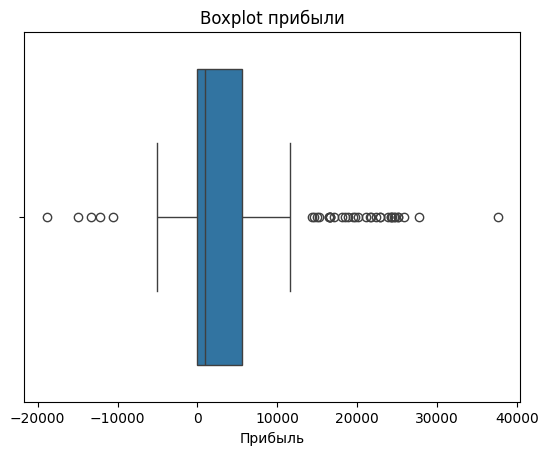

In [81]:
# проверка выбросов
plt.figure()
sns.boxplot(x=df['Прибыль'])
plt.title('Boxplot прибыли')
plt.show()

На графике наблюдаются значительные выбросы в обе стороны: прибыль свыше 12 000 и убытки ниже -5 000. Положительные аномалии указывают на потенциал для масштабирования успеха, тогда как отрицательные сигнализируют о критических рисках (штрафы, возвраты). Высокая волатильность данных требует отдельного изучения причин этих отклонений для стабилизации финансовых показателей.

### Связь заказов и прибыли

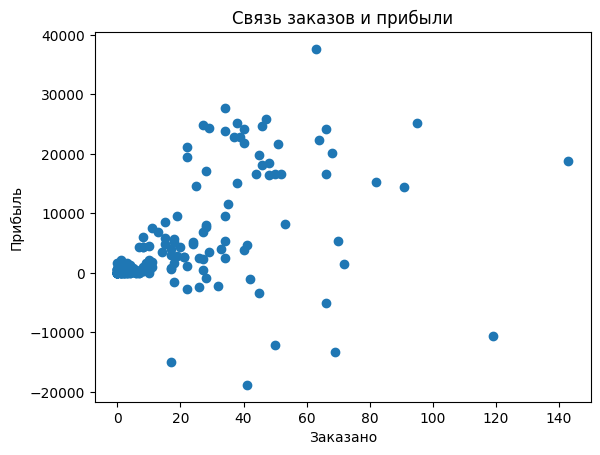

In [82]:
plt.figure()
plt.scatter(df['Заказано'], df['Прибыль'])
plt.title('Связь заказов и прибыли')
plt.xlabel('Заказано')
plt.ylabel('Прибыль')
plt.show()

Наблюдается общая положительная тенденция: увеличение количества заказов, как правило, связано с ростом прибыли. Однако, отсутствие строгой линейности и наличие точек с высоким количеством заказов, но низкой прибылью (или наоборот) указывает на влияние других факторов, таких как маржинальность конкретных товаров, операционные издержки или возвраты. Это говорит о том, что не все заказы одинаково ценны для бизнеса.

### Влияние акций на продажи

In [83]:
# средние значения по акциям
df.groupby('Акция')[['Заказано', 'Прибыль']].mean()

,Заказано,Прибыль
Акция,,
0.0,19.628788,5464.348485
1.0,18.960784,2470.470588


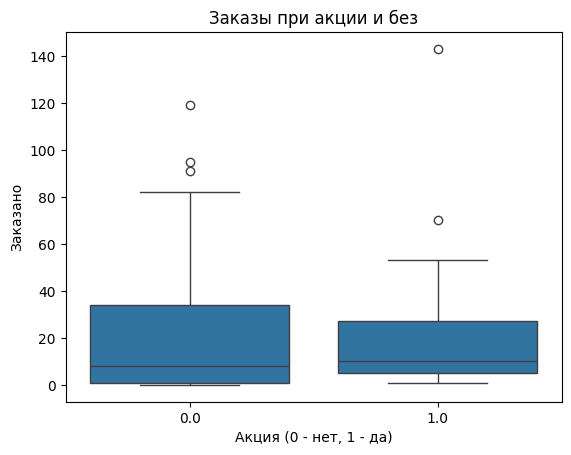

In [84]:
# визуальное сравнение
plt.figure()
sns.boxplot(x=df['Акция'], y=df['Заказано'])
plt.title('Заказы при акции и без')
plt.xlabel('Акция (0 - нет, 1 - да)')
plt.ylabel('Заказано')
plt.show()

Анализ показал, что среднее количество заказов и прибыль для товаров без акций выше, чем для товаров, участвующих в акциях. Это не очевидный результат, который может свидетельствовать о неэффективности текущих акционных стратегий. Возможно, акции применяются к товарам с низкой базовой привлекательностью, или скидки недостаточно велики, чтобы стимулировать значительный рост продаж и прибыли. Требуется пересмотр подхода к акциям.

### Влияние рекламы

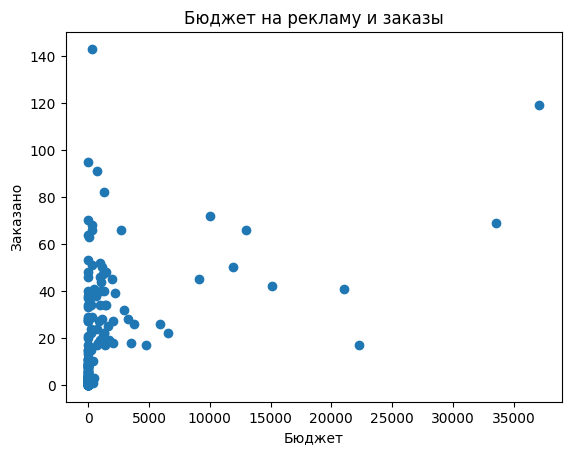

In [85]:
plt.figure()
plt.scatter(df['Бюджет на рекламу'], df['Заказано'])
plt.title('Бюджет на рекламу и заказы')
plt.xlabel('Бюджет')
plt.ylabel('Заказано')
plt.show()

График рассеяния и корреляция показывают слабую положительную связь между бюджетом на рекламу и количеством заказов (корреляция 0.30). Это означает, что увеличение рекламного бюджета не всегда приводит к пропорциональному росту заказов. Эффективность рекламных кампаний, вероятно, низка или требует оптимизации таргетинга, креативов или каналов размещения. Бизнесу стоит глубже анализировать ROI рекламных инвестиций.

## Выводы по EDA

Результаты анализа показывают, что бизнес сталкивается с высокой нестабильностью финансовых показателей. Большинство операций приносят небольшую прибыль или убытки, а редкие случаи высокой доходности не отражают общую картину.

Связь между количеством заказов и прибылью существует, но она не прямолинейна. Увеличение числа заказов не всегда ведет к росту прибыли, что говорит о различиях в ценности отдельных заказов.

Эффективность маркетинговых инструментов вызывает вопросы:

- Товары, участвующие в акциях, показывают более низкие результаты, чем те, которые не были на распродаже. Это указывает на необходимость пересмотра акционной стратегии.

- Рекламный бюджет слабо влияет на количество заказов. Инвестиции в рекламу не дают пропорциональной отдачи.

Основной вывод: для улучшения результатов требуется не просто наращивать объем заказов или рекламные бюджеты, а пересмотреть подход к управлению маржинальностью, акциями и эффективностью рекламных кампаний.


## 4. Формулировка гипотез

### Гипотеза 1: влияние акций на количество заказов

H0: участие в акции не влияет на количество заказов  
H1: участие в акции влияет на количество заказов

In [86]:
group1 = df[df['Акция'] == 1]['Заказано']
group2 = df[df['Акция'] == 0]['Заказано']

stats.ttest_ind(group1, group2, nan_policy='omit')

TtestResult(statistic=np.float64(-0.1676537426288839), pvalue=np.float64(0.8670428614177521), df=np.float64(181.0))

Вывод: p-value (0.867) значительно выше 0.05(порог уверенности). Нет статистически значимых доказательств того, что участие в акции влияет на количество заказов. Нулевая гипотеза (H0) не отвергается. Бизнес-инсайт: Текущие акции не являются эффективным инструментом для увеличения объема продаж. Возможно, они не привлекают достаточного внимания или не стимулируют покупку.

### Гипотеза 2: влияние акций на прибыль

H0: участие в акции не влияет на прибыль  
H1: участие в акции влияет на прибыль

In [87]:
group1 = df[df['Акция'] == 1]['Прибыль']
group2 = df[df['Акция'] == 0]['Прибыль']

stats.ttest_ind(group1, group2, nan_policy='omit')

TtestResult(statistic=np.float64(-2.1088014941299615), pvalue=np.float64(0.036337466009371856), df=np.float64(181.0))

Вывод: p-value (0.036) ниже 0.05. Существует статистически значимое влияние акций на прибыль. Отрицательное значение t-статистики (-2.109) указывает, что товары в акциях приносят статистически значимо меньшую прибыль. Нулевая гипотеза (H0) отвергается. Бизнес-инсайт: Акции, как они проводятся сейчас, не только не увеличивают заказы, но и снижают общую прибыльность. Необходимо пересмотреть акционную политику, возможно, фокусироваться на других стимулах или более маржинальных товарах.

### Гипотеза 3: влияние рекламного бюджета на количество заказов

H0: между бюджетом на рекламу и количеством заказов нет связи  
H1: существует зависимость

In [88]:
stats.pearsonr(df['Бюджет на рекламу'], df['Заказано'])

PearsonRResult(statistic=np.float64(0.42336724337332177), pvalue=np.float64(2.3555439573077006e-09))

Вывод: p-value (2.36e-09) очень мало, коэффициент корреляции Пирсона (0.423) умеренно положительный. Существует статистически значимая умеренная положительная зависимость между рекламным бюджетом и количеством заказов. Нулевая гипотеза (H0) отвергается. Бизнес-инсайт: Реклама в целом работает и приводит к увеличению заказов, но ее эффективность не идеальна. Есть потенциал для оптимизации рекламных кампаний, чтобы получить больший прирост заказов на единицу бюджета.

### Гипотеза 4: влияние рекламного бюджета на прибыль

H0: между бюджетом на рекламу и прибылью нет связи  
H1: существует зависимость

In [89]:
stats.pearsonr(df['Бюджет на рекламу'], df['Прибыль'])

PearsonRResult(statistic=np.float64(-0.3223373250678256), pvalue=np.float64(8.587977518202008e-06))

Вывод: p-value (8.59e-06) очень мало, коэффициент корреляции Пирсона (-0.322) слабая отрицательная. Существует статистически значимая, но слабая отрицательная зависимость между рекламным бюджетом и прибылью. Нулевая гипотеза (H0) отвергается. Бизнес-инсайт: Несмотря на то, что реклама увеличивает заказы, она при этом снижает прибыль. Это критический момент, указывающий на то, что рекламные расходы слишком высоки относительно получаемой прибыли, или рекламируются низкомаржинальные товары. Необходим срочный пересмотр стратегии рекламных инвестиций с фокусом на ROI.

### Гипотеза 5: влияние цены на количество заказов

H0: цена не влияет на количество заказов  
H1: цена влияет на количество заказов

In [90]:
stats.pearsonr(df['Цена'], df['Заказано'])

PearsonRResult(statistic=np.float64(-0.5272202383700624), pvalue=np.float64(1.7549963752548614e-14))

Вывод: p-value (1.75e-14) очень мало, коэффициент корреляции Пирсона (-0.527) умеренно отрицательный. Существует статистически значимая умеренная отрицательная зависимость: с ростом цены количество заказов, как правило, снижается. Нулевая гипотеза (H0) отвергается. Бизнес-инсайт: Это подтверждает базовый экономический принцип эластичности спроса. Увеличение цены ведет к падению спроса. При ценообразовании важно находить баланс между объемом продаж и маржинальностью, возможно, через сегментацию товаров или A/B-тестирование цен.

### Гипотеза 6: влияние процента выкупа на прибыль

H0: процент выкупа не влияет на прибыль  
H1: процент выкупа влияет на прибыль

In [91]:
stats.pearsonr(df['% выкупа'], df['Прибыль'])

PearsonRResult(statistic=np.float64(0.4456777579867252), pvalue=np.float64(2.578322294888391e-10))

Вывод: p-value (2.58e-10) очень мало, коэффициент корреляции Пирсона (0.446) умеренно положительный. Существует статистически значимая умеренная положительная зависимость между процентом выкупа и прибылью. Нулевая гипотеза (H0) отвергается. Бизнес-инсайт: Высокий процент выкупа напрямую связан с большей прибылью. Это подчеркивает важность работы над качеством товара, точным описанием, соответствием размерной сетке и быстрой доставкой, чтобы минимизировать возвраты и увеличить выкуп.

## 5. Итоговые выводы

Проведенный статистический анализ данных Wildberries выявил ряд важных закономерностей, которые требуют внимания для оптимизации бизнес-процессов и повышения прибыльности:

1. Неэффективность акционных стратегий: Текущие акции не только не стимулируют рост количества заказов, но и статистически значимо снижают общую прибыль. Рекомендация: Срочно пересмотреть подход к акциям. Провести A/B-тестирование различных акционных механик, тщательно отбирать товары для акций (фокусируясь на высокомаржинальных или товарах-локомотивах), а также анализировать влияние акций на долгосрочную лояльность клиентов, а не только на краткосрочные продажи.

2. Проблемы с рекламными инвестициями: Реклама увеличивает количество заказов, но при этом негативно влияет на прибыль. Это указывает на неоптимальное распределение рекламного бюджета или рекламу низкомаржинальных товаров. Рекомендация: Провести глубокий аудит рекламных кампаний. Оценить ROI каждой кампании, оптимизировать таргетинг и креативы. Возможно, стоит перераспределить бюджет в пользу органического трафика или других каналов, которые демонстрируют лучшую окупаемость. Необходимо фокусироваться не только на объеме заказов, но и на их прибыльности.

3. Важность процента выкупа: Высокий процент выкупа напрямую коррелирует с ростом прибыли. Рекомендация: Усилить работу над факторами, влияющими на выкуп: улучшение качества товаров, максимально точное описание и фотографии, соответствие размерной сетке, а также оптимизация логистики для сокращения сроков доставки и повышения удовлетворенности клиентов.

4. Ценовая политика: Цена ожидаемо влияет на количество заказов. Рекомендация: Разработать более гибкую ценовую стратегию. Использовать динамическое ценообразование, проводить A/B-тестирование цен для разных сегментов аудитории и товаров, чтобы найти оптимальный баланс между объемом продаж и прибылью. Возможно, для некоторых товаров стоит рассмотреть повышение цен, если это не приведет к значительному падению спроса, но существенно увеличит маржинальность.

Общий вывод: Для устойчивого роста на Wildberries необходимо перейти от простого увеличения объемов продаж к стратегии, ориентированной на прибыльность. Это потребует более глубокого анализа каждого элемента воронки продаж, от привлечения клиента до его выкупа, и принятия решений, основанных на данных, а не на интуиции или стандартных подходах.

